In [1]:
import gzip
import os
import matplotlib.pyplot as plt

def plot_fastq_read_counts(fastq_files, sample_names=None, title="FASTQ Read Counts"):
    """
    Count reads in FASTQ/FASTQ.GZ files and plot a simple barplot.
    
    Parameters:
        fastq_files : list of str
            Paths to FASTQ or FASTQ.GZ files.
        sample_names : list of str, optional
            Names for samples (default: filenames).
        title : str
            Title for the barplot.
    """
    read_counts = []

    for fq in fastq_files:
        if not os.path.exists(fq):
            print(f"Warning: File not found: {fq}")
            read_counts.append(0)
            continue
        
        open_func = gzip.open if fq.endswith(".gz") else open
        with open_func(fq, "rt") as f:
            count = sum(1 for _ in f) // 4  # 4 lines per read
        read_counts.append(count)
    
    if sample_names is None:
        sample_names = [os.path.basename(f) for f in fastq_files]
    
    # Simple barplot
    plt.figure(figsize=(10,5))
    plt.bar(sample_names, read_counts, color="skyblue")
    plt.ylabel("Number of reads")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    for i, val in enumerate(read_counts):
        plt.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
    
    return read_counts

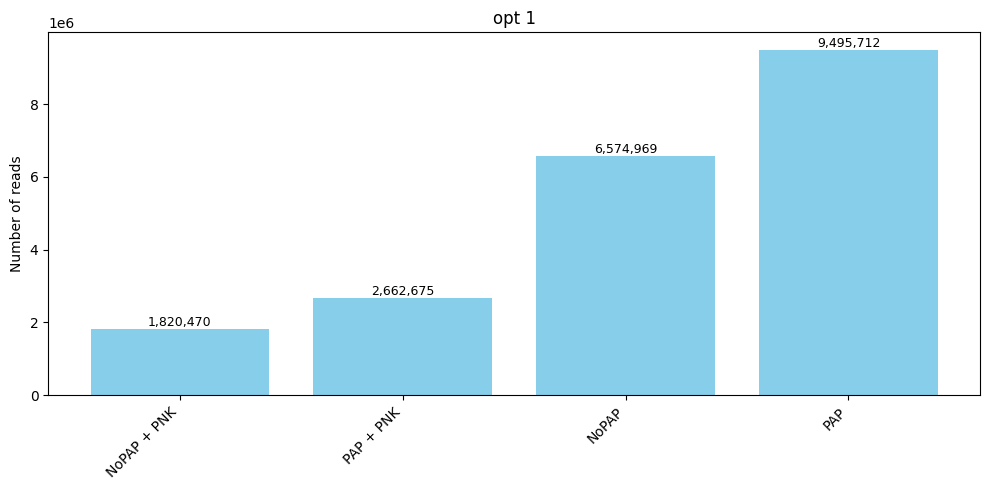

In [2]:
fastq_files = [
    "Opt1_no_polyA_trim/EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "Opt1_no_polyA_trim/EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "Opt1_no_polyA_trim/EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "Opt1_no_polyA_trim/EED_gut_PAP_S2_R2_001_fastped.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="opt 1")

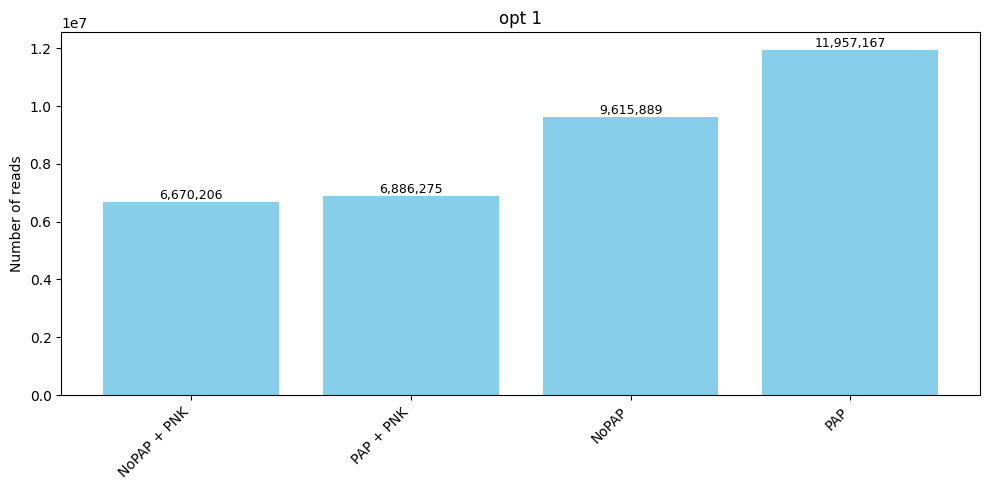

In [3]:
fastq_files = [
    "Opt2_no_read_removal_byLen/EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "Opt2_no_read_removal_byLen/EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "Opt2_no_read_removal_byLen/EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "Opt2_no_read_removal_byLen/EED_gut_PAP_S2_R2_001_fastped.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="opt 2")

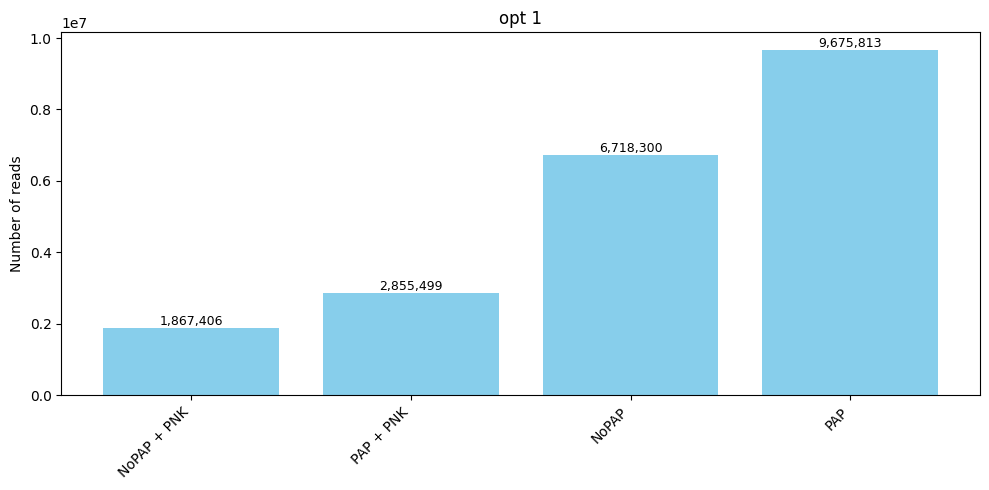

In [4]:
fastq_files = [
    "Opt3_the_same_asOpt2_but_minLen_30/EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "Opt3_the_same_asOpt2_but_minLen_30/EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "Opt3_the_same_asOpt2_but_minLen_30/EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "Opt3_the_same_asOpt2_but_minLen_30/EED_gut_PAP_S2_R2_001_fastped.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="opt 3")

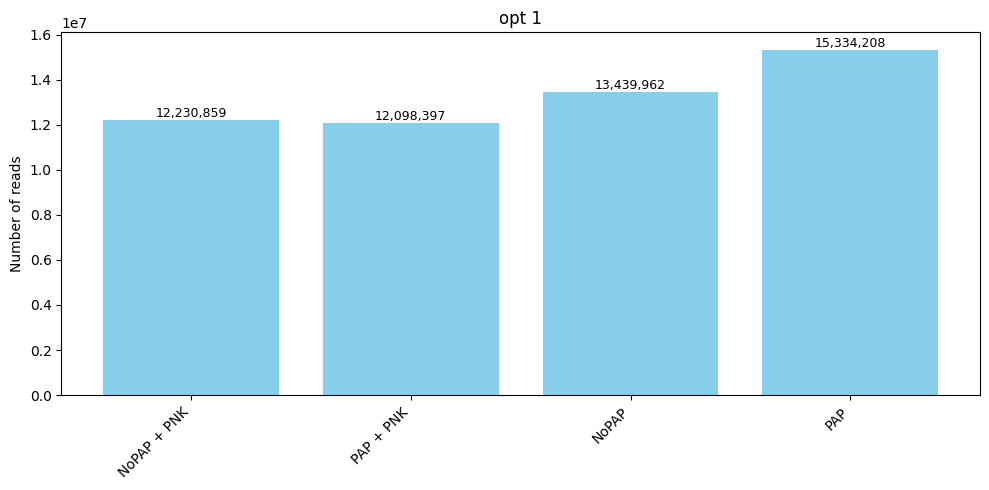

In [5]:
fastq_files = [
    "Opt4_opt3_but_only_adapters_from_Sara/EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "Opt4_opt3_but_only_adapters_from_Sara/EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "Opt4_opt3_but_only_adapters_from_Sara/EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "Opt4_opt3_but_only_adapters_from_Sara/EED_gut_PAP_S2_R2_001_fastped.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="opt 4")

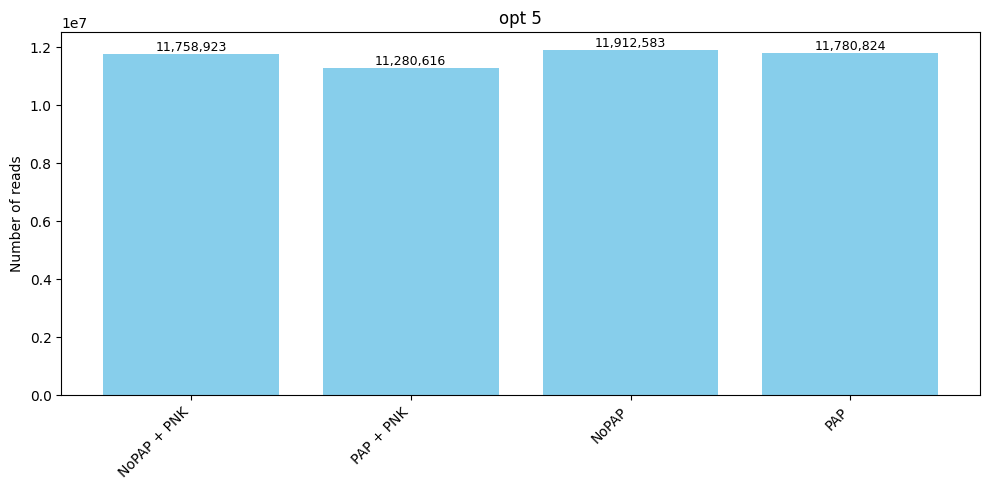

In [6]:
fastq_files = [
    "Opt5_opt4+remove_dups/EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
    "Opt5_opt4+remove_dups/EED_gut_PAP_PNK_S4_R2_001_fastped.fastq",
    "Opt5_opt4+remove_dups/EED_gut_NoPAP_S1_R2_001_fastped.fastq",
    "Opt5_opt4+remove_dups/EED_gut_PAP_S2_R2_001_fastped.fastq"
]

sample_names = ["NoPAP + PNK", "PAP + PNK", "NoPAP", "PAP"]

read_counts = plot_fastq_read_counts(fastq_files, sample_names, title="opt 5")

In [20]:

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import gzip

# ---- INPUT FILES ----
kraken_files = [
    "EED_gut_NoPAP_S1_R2_001_k2.csv",
    "EED_gut_PAP_S2_R2_001_k2.csv",
    "EED_gut_NoPAP_PNK_S3_R2_001_k2.csv",
    "EED_gut_PAP_PNK_S4_R2_001_k2.csv"
]

#fastq_files = [
#        "EED_gut_NoPAP_S1_R2_001_fastped_bwa_unhosted.fastq",
#        "EED_gut_PAP_S2_R2_001_fastped_bwa_unhosted.fastq",
#        "EED_gut_NoPAP_PNK_S3_R2_001_fastped_bwa_unhosted.fastq",
#        "EED_gut_PAP_PNK_S4_R2_001_fastped_bwa_unhosted.fastq"]

fastq_files = [
        "EED_gut_NoPAP_S1_R2_001_fastped.fastq",
        "EED_gut_PAP_S2_R2_001_fastped.fastq",
        "EED_gut_NoPAP_PNK_S3_R2_001_fastped.fastq",
        "EED_gut_PAP_PNK_S4_R2_001_fastped.fastq"]


labels = ["NoPAP", "PAP", "NoPAP_PNK", "PAP_PNK"]

# ---- CALCULATE METRICS ----
human_taxid = 9606
cutoff_fraction = 0      # 0.05% of total reads
min_absolute_reads = 0       # minimum reads per taxon

def count_fastq_reads(fastq_file):
    """Count reads in FASTQ (handles .gz)"""
    open_func = gzip.open if fastq_file.endswith(".gz") else open
    with open_func(fastq_file, "rt") as f:
        return sum(1 for _ in f) // 4

def count_filtered_reads(kraken_file, total_reads, cutoff_fraction=cutoff_fraction, min_absolute_reads=min_absolute_reads):
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads * cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts >= min_reads]
    return taxa_counts.sum()

def count_filtered_unique_taxa(kraken_file, total_reads, cutoff_fraction=cutoff_fraction, min_absolute_reads=min_absolute_reads):
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    taxa_counts = df[2].value_counts()
    min_reads = max(total_reads * cutoff_fraction, min_absolute_reads)
    taxa_counts = taxa_counts[taxa_counts >= min_reads]
    return len(taxa_counts)



mapped_percent = []
unique_taxa = []

for kfile, ffile in zip(kraken_files, fastq_files):

    total_reads = count_fastq_reads(ffile)

    mapped_reads = count_filtered_reads(kfile, total_reads)
    percent = (mapped_reads / total_reads) * 100

    taxa = count_filtered_unique_taxa(kfile, total_reads)

    mapped_percent.append(percent)
    unique_taxa.append(taxa)



/scratch/ipykernel_1596641/1382300584.py:41: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_1596641/1382300584.py:49: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_1596641/1382300584.py:41: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_1596641/1382300584.py:49: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
/scratch/ipykernel_1596641/1382300584.py:41: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(kraken_file, hea

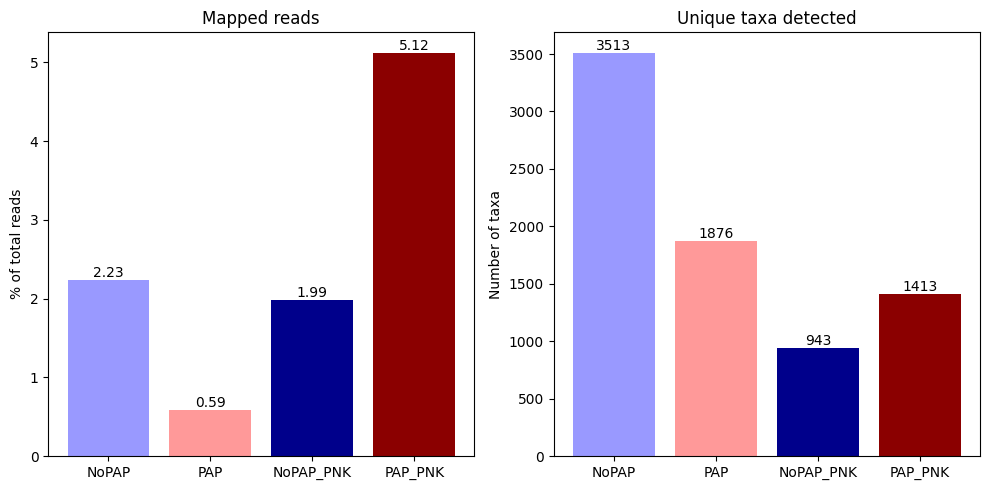

In [21]:
# ---- PLOTTING ----
fig, axes = plt.subplots(1, 2, figsize=(10,5))

#colors = ["skyblue", "orange"]
colors = ['#9999ff','#ff9999', '#00008b', '#8b0000']  # PAP, NoPAP, NoPAP_PNK, PAP_PNK

# subplot 1 — mapped reads %
axes[0].bar(labels, mapped_percent, color=colors)
axes[0].set_title("Mapped reads")
axes[0].set_ylabel("% of total reads")

for i, v in enumerate(mapped_percent):
    axes[0].text(i, v, f"{v:.2f}", ha="center", va="bottom")

# subplot 2 — unique taxa
axes[1].bar(labels, unique_taxa, color=colors)
axes[1].set_title("Unique taxa detected")
axes[1].set_ylabel("Number of taxa")

for i, v in enumerate(unique_taxa):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [8]:
# ---- FUNCTIONS ----
def count_fastq_reads(fastq_file):
    """Count reads in FASTQ (handles .gz)"""
    open_func = gzip.open if fastq_file.endswith(".gz") else open
    with open_func(fastq_file, "rt") as f:
        return sum(1 for _ in f) // 4

def count_filtered_reads(kraken_file, abundance_threshold=0.01):
    """
    Count reads for taxa whose relative abundance exceeds a threshold.
    Ensures each taxon is counted only once, summing all its reads.
    """
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    
    if df.empty:
        return 0
    
    # sum reads per taxon
    taxa_counts = df.groupby(2).size()
    total_reads = taxa_counts.sum()
    
    # keep taxa with relative abundance > threshold
    filtered_taxa = taxa_counts[taxa_counts / total_reads > abundance_threshold]
    return filtered_taxa.sum()


def count_filtered_unique_taxa(kraken_file, abundance_threshold=0.01):
    """
    Count unique taxa whose relative abundance exceeds a threshold.
    """
    df = pd.read_csv(kraken_file, header=None, usecols=[0,2])
    df = df[(df[0] == "C") & (df[2] != human_taxid)]
    
    if df.empty:
        return 0
    
    # sum reads per taxon
    taxa_counts = df.groupby(2).size()
    total_reads = taxa_counts.sum()
    filtered_taxa = taxa_counts[taxa_counts / total_reads > abundance_threshold]
    return len(filtered_taxa)